Loading libraries I will need. Note geopandas will help us assigning the latitudes and longitudes to each province.

In [97]:
import pandas as pd
import geopandas as gpd
import os

Now I will define the paths were I have downloaded the FIRMS datasets and where I have my GADM shapefile data that I will use to determine the Spanish coordinates of each province.

In [100]:
base_path = r"C:\Users\ealda\Downloads"
shapefile_path = r"C:\Users\ealda\Downloads\gadm41_ESP_shp\gadm41_ESP_2.shp"

I define the training and validation years.

In [103]:
training_years = range(2003,2023)
validation_years = range(2023,2025)

For each year, this function builds the expected file path, checks if the file exists, and loads it as a pandas dataframe. It also extracts the year and month from the acquisition date, which we will need later for modelling. If a file is missing it prints a warning and returns None instead of crashing.

In [106]:
def load_year(year):
    path = os.path.join(
        base_path,
        "modis_{}_all_countries".format(year),
        "modis",
        str(year),
        "modis_{}_Spain.csv".format(year)
    )
    if os.path.exists(path):
        df = pd.read_csv(path, parse_dates=["acq_date"])
        df["year"]  = df["acq_date"].dt.year
        df["month"] = df["acq_date"].dt.month
        print("  Loaded {}: {:,} rows".format(year, len(df)))
        return df
    else:
        print("  WARNING: File not found for {} — {}".format(year, path))
        return None

This code loops through each training year, loads the Spain CSV, and concatenates all years into a single dataframe. This will be used to train the model.

In [109]:
print("\nLoading training years (2003–2022)...")
frames_train = [load_year(y) for y in training_years]
frames_train = [f for f in frames_train if f is not None]
df_train = pd.concat(frames_train, ignore_index=True)
print("\nTraining dataset ready: {:,} rows total\n".format(len(df_train)))


Loading training years (2003–2022)...
  Loaded 2003: 7,475 rows
  Loaded 2004: 7,897 rows
  Loaded 2005: 6,979 rows
  Loaded 2006: 7,219 rows
  Loaded 2007: 4,417 rows
  Loaded 2008: 3,003 rows
  Loaded 2009: 4,623 rows
  Loaded 2010: 2,708 rows
  Loaded 2011: 5,453 rows
  Loaded 2012: 6,185 rows
  Loaded 2013: 3,453 rows
  Loaded 2014: 2,603 rows
  Loaded 2015: 3,174 rows
  Loaded 2016: 3,211 rows
  Loaded 2017: 5,183 rows
  Loaded 2018: 1,681 rows
  Loaded 2019: 3,300 rows
  Loaded 2020: 2,602 rows
  Loaded 2021: 4,725 rows
  Loaded 2022: 5,925 rows

Training dataset ready: 91,816 rows total



This codes does the same as above but for the testing years (2024 and 2025).

In [112]:
print("Loading validation years (2023–2024)...")
frames_val = [load_year(y) for y in validation_years]
frames_val = [f for f in frames_val if f is not None]
df_val = pd.concat(frames_val, ignore_index=True)
print("\nValidation dataset ready: {:,} rows total\n".format(len(df_val)))

Loading validation years (2023–2024)...
  Loaded 2023: 2,802 rows
  Loaded 2024: 2,110 rows

Validation dataset ready: 4,912 rows total



Now we load the GADM Level 2 shapefile for Spain, which contains the polygon boundaries for all 52 Spanish provinces. We only keep the province name (NAME_2) and geometry columns, and reproject to EPSG:4326 (standard latitude/longitude) to match the coordinate system of the fire data. The encoding="utf-8" ensures accented characters (á, é, ñ etc.) display correctly in province names like Almería or Córdoba.

In [115]:
print("Loading provinces shapefile...")
provinces = gpd.read_file(shapefile_path, encoding="utf-8")[["NAME_2", "geometry"]].to_crs("EPSG:4326")
print("  Provinces loaded: {}".format(len(provinces)))
print("  Sample province names:", list(provinces["NAME_2"].head(5)))

Loading provinces shapefile...
  Provinces loaded: 52
  Sample province names: ['Almería', 'Cádiz', 'Córdoba', 'Granada', 'Huelva']


For each fire detection, we check which province polygon its latitude and longitude coordinates fall inside, and record that province name in a new column called "province". This is done using a spatial join in geopandas. Any detections that fall outside all province polygons (typically coastal or border pixels) are flagged as unmatched and reported.

In [118]:
def assign_province(df, provinces, label):
    print("\nAssigning provinces to {}...".format(label))
    gdf = gpd.GeoDataFrame(
        df.copy(),
        geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
        crs="EPSG:4326"
    )
    joined = gpd.sjoin(gdf, provinces, how="left", predicate="within")
    joined = joined.rename(columns={"NAME_2": "province"})
    joined = joined.drop(columns=["index_right", "geometry"])
    unmatched = joined["province"].isna().sum()
    print("  Unmatched detections (outside province boundaries): {:,}".format(unmatched))
    return pd.DataFrame(joined)

df_train = assign_province(df_train, provinces, "training set (2003-2022)")
df_val   = assign_province(df_val,   provinces, "validation set (2023-2024)")


Assigning provinces to training set (2003-2022)...
  Unmatched detections (outside province boundaries): 626

Assigning provinces to validation set (2023-2024)...
  Unmatched detections (outside province boundaries): 22


Now we start our EDA, by printing the top 10 provinces by total fire detections in the training set so we can do a quick visual check that province assignment looks sensible.

In [120]:
print("\nTop 10 provinces by fire detections (training set):")
print(df_train["province"].value_counts().head(10))


Top 10 provinces by fire detections (training set):
province
Asturias                  7885
Ourense                   7827
León                      5309
Sevilla                   4896
Badajoz                   4108
A Coruña                  3900
Pontevedra                3413
Cáceres                   3298
Zamora                    2808
Santa Cruz de Tenerife    2671
Name: count, dtype: int64


For data visualization we include two charts to explosre the cleaned data:
- A bar chart showing fire detections by year
- A horizontal bar chart showing total fire detections by province

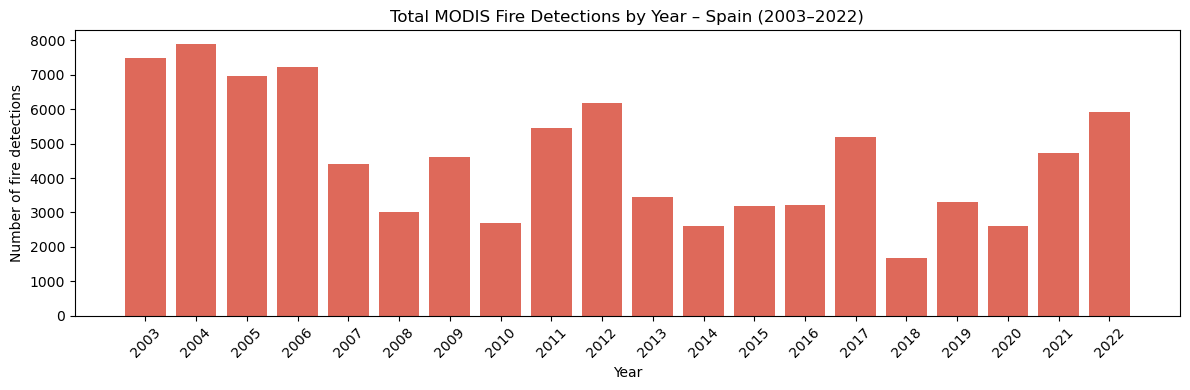

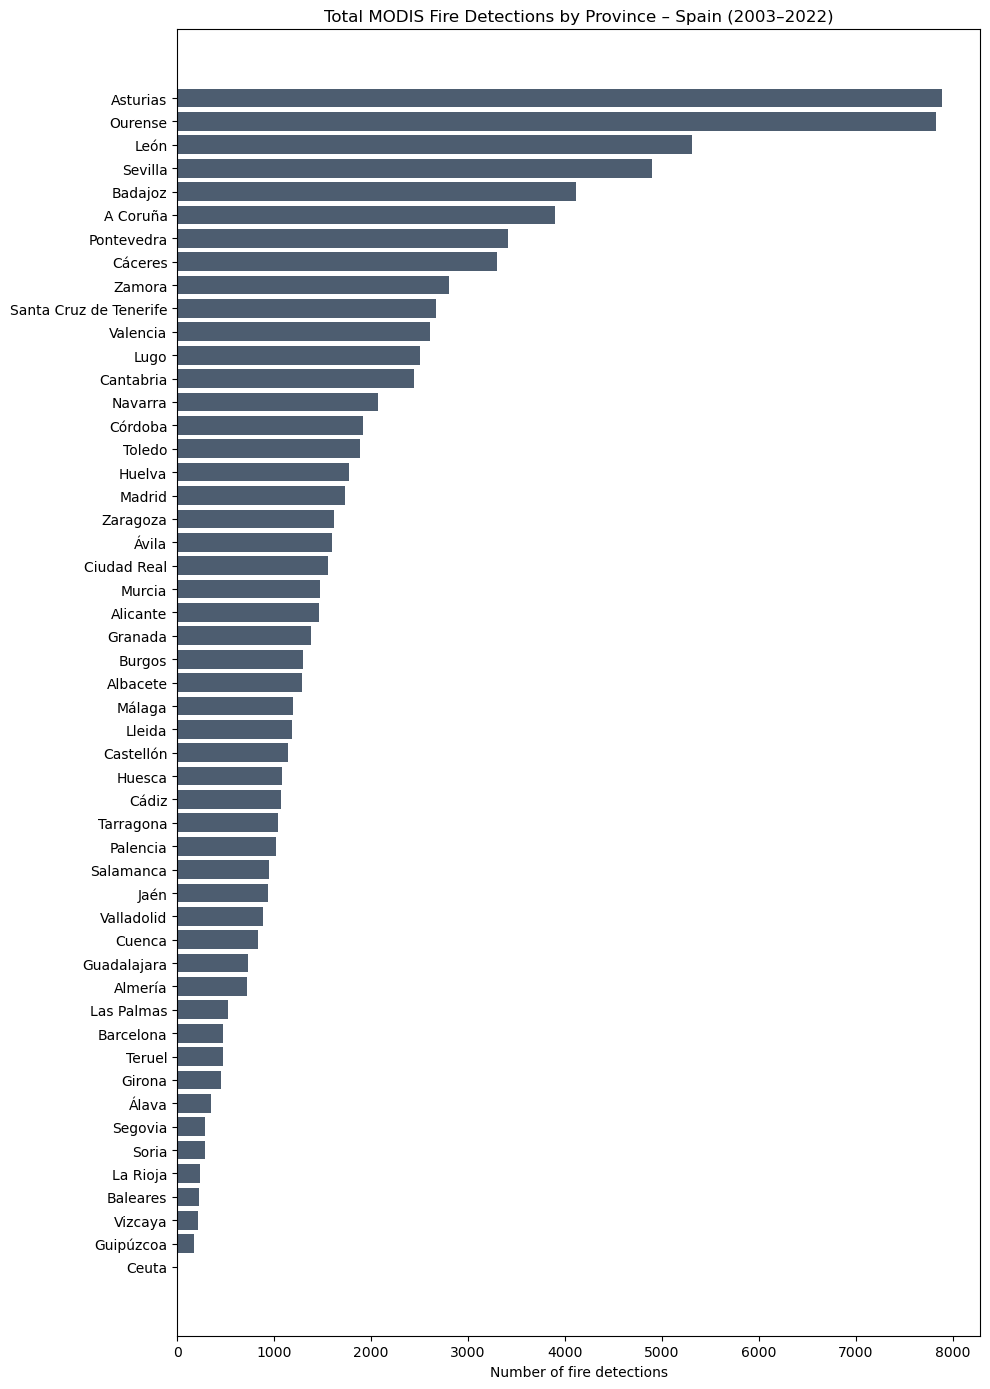

In [125]:
# Chart 1: Fire detections by year
fires_by_year = df_train.groupby("year").size().reset_index(name="fire_count")
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(fires_by_year["year"], fires_by_year["fire_count"], color="#D94F3D", alpha=0.85)
ax.set_xlabel("Year")
ax.set_ylabel("Number of fire detections")
ax.set_title("Total MODIS Fire Detections by Year – Spain (2003–2022)")
ax.set_xticks(fires_by_year["year"])
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# Chart 2: Fire detections by province
fires_by_province = df_train.groupby("province").size().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(fires_by_province.index, fires_by_province.values, color="#2E4057", alpha=0.85)
ax.set_xlabel("Number of fire detections")
ax.set_title("Total MODIS Fire Detections by Province – Spain (2003–2022)")
plt.tight_layout()
plt.show()

We save both datasets as CSV files in the Downloads folder. Note that "encoding=utf-8-sig" ensures that accented characters in province names display correctly when opening the files in Excel or other tools.

In [123]:
df_train.to_csv(os.path.join(base_path, "firms_spain_2003_2022_provinces.csv"), index=False, encoding="utf-8-sig")
df_val.to_csv(  os.path.join(base_path, "firms_spain_2023_2024_provinces.csv"), index=False, encoding="utf-8-sig")
print("\nDone! Files saved to:")
print("  {}".format(os.path.join(base_path, "firms_spain_2003_2022_provinces.csv")))
print("  {}".format(os.path.join(base_path, "firms_spain_2023_2024_provinces.csv")))
print("\nRows saved:")
print("  Training (2003-2022):   {} rows".format(len(df_train)))
print("  Validation (2023-2024): {} rows".format(len(df_val)))


Done! Files saved to:
  C:\Users\ealda\Downloads\firms_spain_2003_2022_provinces.csv
  C:\Users\ealda\Downloads\firms_spain_2023_2024_provinces.csv

Rows saved:
  Training (2003-2022):   91816 rows
  Validation (2023-2024): 4912 rows
